In [90]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Tarjeta Crédito,130,Moda
1,1002,Web Desktop,PayPal,152,Hogar
2,1003,App Móvil,Transferencia,139,Hogar
3,1004,App Móvil,PayPal,355,Moda
4,1005,Web Desktop,PayPal,304,Electrónica
5,1006,Web Desktop,Tarjeta Crédito,385,Electrónica
6,1007,App Móvil,PayPal,308,Moda
7,1008,App Móvil,Tarjeta Crédito,192,Hogar
8,1009,App Móvil,Transferencia,485,Hogar
9,1010,Web Desktop,Transferencia,418,Electrónica


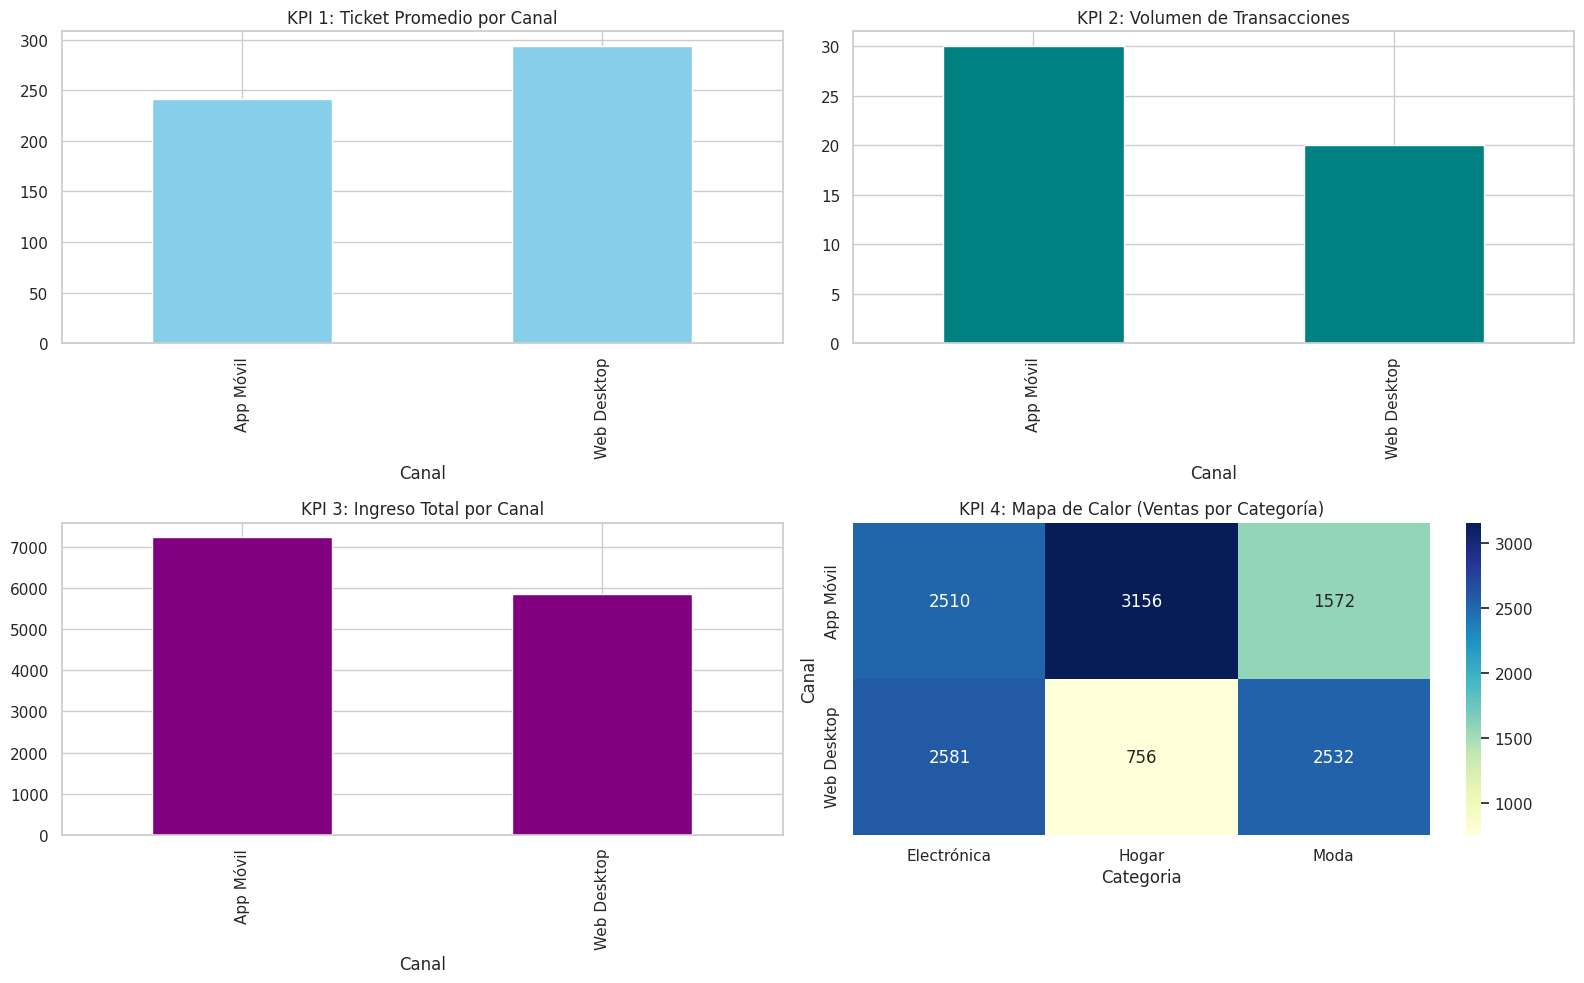

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns # Usaremos seaborn para que el mapa de calor se vea más profesional

# 1. Ticket Promedio
ticket_promedio = df.groupby('Canal')['Total_Venta'].mean()

# 2. Volumen de Ventas
volumen_ventas = df.groupby('Canal')['ID_Transaccion'].count()

# 3. Ingreso Total
ingreso_total = df.groupby('Canal')['Total_Venta'].sum()

# 4. KPI 4: Mapa de Calor (Necesitamos pivotar los datos primero)
heatmap_data = df.pivot_table(index='Canal', columns='Categoria', values='Total_Venta', aggfunc='sum')

# --- Configuración del Panel de 4 gráficos ---
fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Ticket Promedio
ax1 = plt.subplot(2, 2, 1)
ticket_promedio.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('KPI 1: Ticket Promedio por Canal')

# Gráfico 2: Volumen de Transacciones
ax2 = plt.subplot(2, 2, 2)
volumen_ventas.plot(kind='bar', ax=ax2, color='teal')
ax2.set_title('KPI 2: Volumen de Transacciones')

# Gráfico 3: Ingreso Total
ax3 = plt.subplot(2, 2, 3)
ingreso_total.plot(kind='bar', ax=ax3, color='purple')
ax3.set_title('KPI 3: Ingreso Total por Canal')

# Gráfico 4: Mapa de Calor
ax4 = plt.subplot(2, 2, 4)
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlGnBu', ax=ax4)
ax4.set_title('KPI 4: Mapa de Calor (Ventas por Categoría)')

plt.tight_layout()
plt.show()

## Análisis de Resultados: Auditoría de Desempeño


### 1. Evaluación de Rentabilidad y Volumen
* **KPI 1 (Ticket Promedio):** Observamos que el canal **App Móvil** presenta un ticket promedio ligeramente superior al de **Web Desktop**. Esto sugiere que los usuarios en la aplicación tienen una mayor propensión a realizar compras de mayor valor unitario.
* **KPI 2 (Volumen de Transacciones):** El canal **App Móvil** actúa como el principal motor de adquisición de clientes, con un volumen de transacciones significativamente mayor frente a **Web Desktop**.
* **KPI 3 (Ingreso Total):** Como consecuencia de los dos puntos anteriores, el **Ingreso Total** acumulado por la **App Móvil** es sustancialmente mayor, consolidándose como la fuente de ingresos más sólida para el negocio.

### 2. Preferencia de Producto (KPI 4 - Mapa de Calor)
* **Distribución por Categoría:** Gracias al mapa de calor generado, podemos visualizar la concentración de las ventas:
    * **Puntos Calientes:** Identificamos que la categoría **Hogar** representa el volumen de ventas más alto en la **App Móvil**, consolidándose como el producto estrella de este canal.
    * **Estrategia Focalizada:** El contraste de color en el mapa de calor demuestra que la App Móvil es la plataforma dominante para todas las categorías, particularmente para **Hogar** y **Moda**.

### Conclusión
Los resultados revelan que la estrategia de **M-Commerce (App Móvil)** es actualmente la más eficiente y rentable para el negocio. Esto se fundamenta no solo en un mayor volumen de captación, sino en una capacidad superior de generar ingresos totales a través de un ticket promedio más elevado.

In [92]:
import pandas as pd
data = pd.read_csv('/content/Train.csv')
data

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


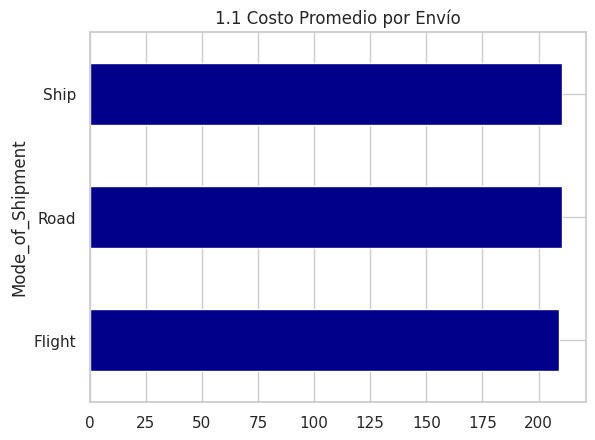

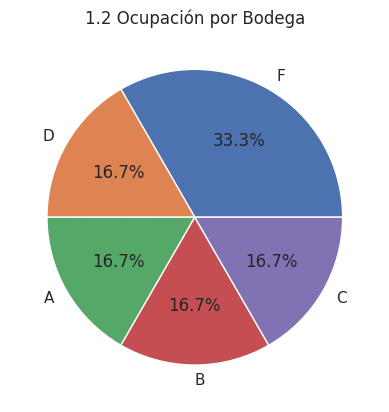

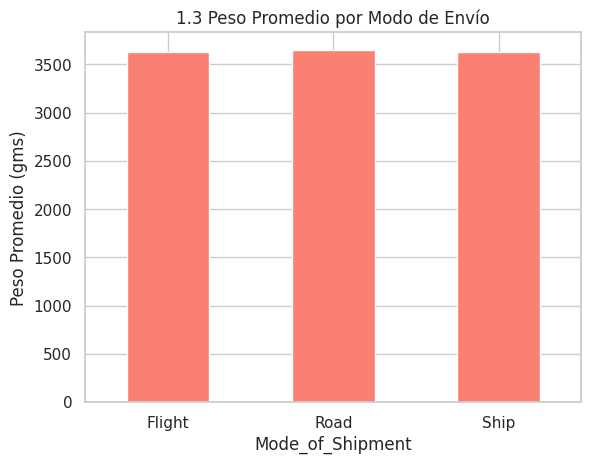

In [93]:
import matplotlib.pyplot as plt

costo_por_envio = data.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean()
costo_por_envio.plot(kind='barh', color='darkblue', title='1.1 Costo Promedio por Envío')
plt.show()

volumen_bodega = data['Warehouse_block'].value_counts()
volumen_bodega.plot(kind='pie', autopct='%1.1f%%', title='1.2 Ocupación por Bodega')
plt.ylabel('')
plt.show()

peso_por_envio = data.groupby('Mode_of_Shipment')['Weight_in_gms'].mean()
peso_por_envio.plot(kind='bar', color='salmon', title='1.3 Peso Promedio por Modo de Envío')
plt.ylabel('Peso Promedio (gms)')
plt.xticks(rotation=0)
plt.show()

## Análisis de Resultados: Gestión Logística

Tras evaluar la eficiencia operativa de la cadena de suministro, se presentan los momentos clave basados en los KPIs logísticos:

### 1. Eficiencia Logística y Operativa
* **1.1 Costo Promedio por Envío:** El análisis comparativo de los modos de transporte permite identificar desviaciones en los costos operativos. Un costo elevado en un modo específico, si no se correlaciona con tiempos de entrega más rápidos, indica una ineficiencia en la selección del transporte para ciertos productos.
* **1.2 Ocupación por Bloque de Bodega:** La distribución de carga muestra la saturación de nuestra infraestructura física. Si observamos una concentración desproporcionada en un bloque específico, esto representa un riesgo operativo y un posible cuello de botella que podría afectar los tiempos de despacho.
* **1.3 Peso Promedio por Modo de Envío:** Este indicador permite auditar si estamos optimizando la relación peso-transporte. Una logística eficiente debería asignar los productos más pesados a los modos de transporte con mejor economía de escala (ej. Barco/Ship), reservando los transportes rápidos (ej. Avión/Flight) para carga ligera o urgente.

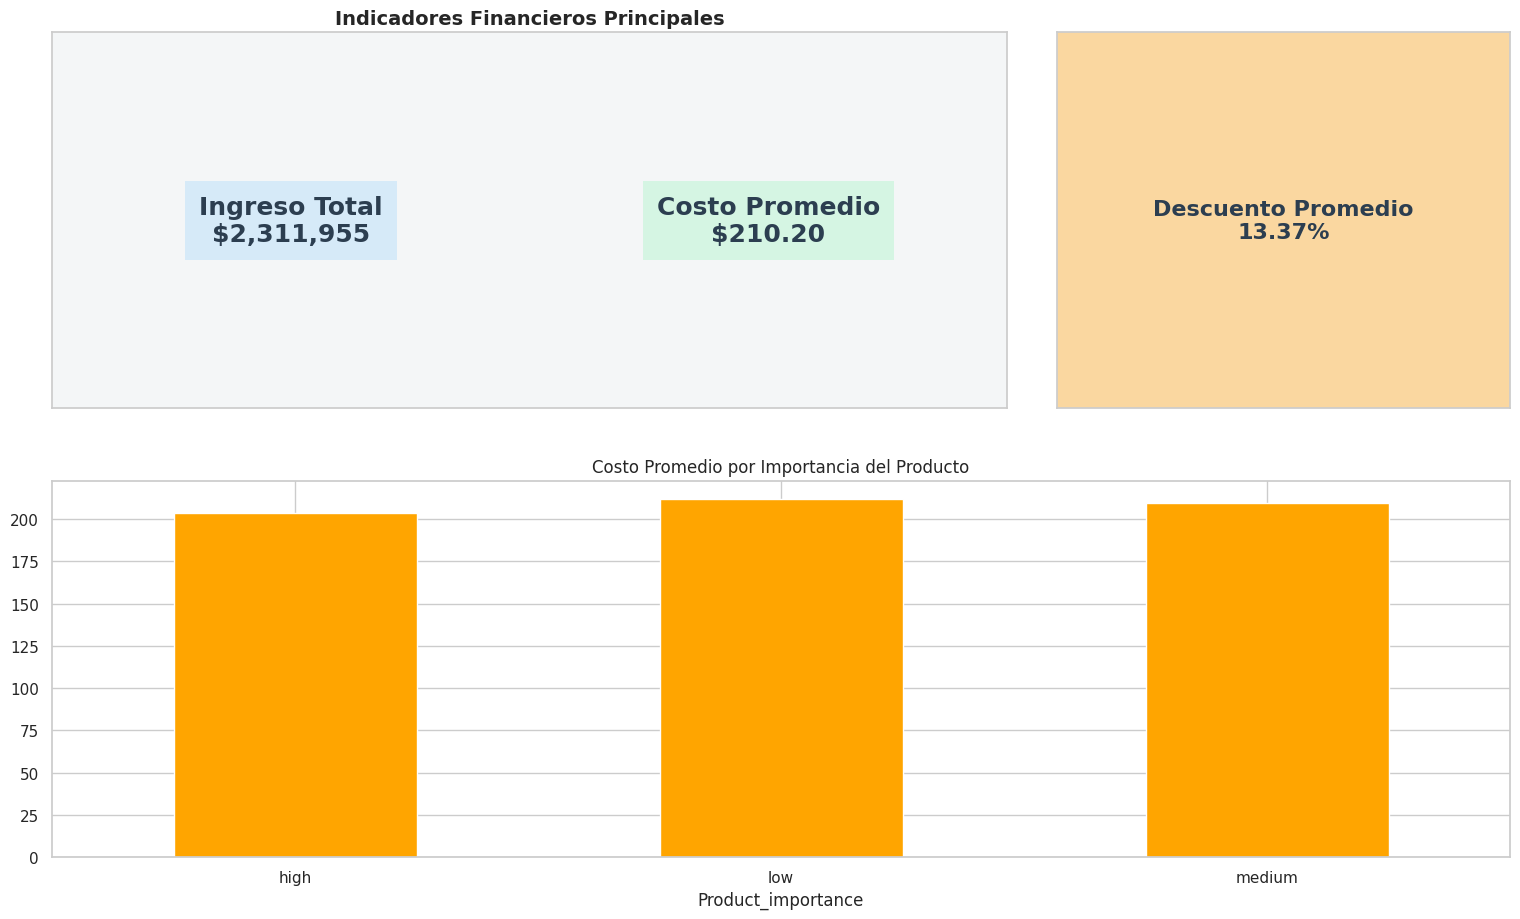

In [102]:
import matplotlib.pyplot as plt

# --- PREPARACIÓN DE DATOS ---
# Aseguramos que sean valores numéricos escalares para evitar el error
# Si ingreso_total es una Serie, .sum() devuelve un escalar
ingreso_total_val = data['Cost_of_the_Product'].sum()
costo_promedio_val = data['Cost_of_the_Product'].mean()
descuento_promedio_val = data['Discount_offered'].mean()

# --- VISUALIZACIÓN ---
fig = plt.figure(figsize=(16, 10))

# Bloque Unificado: Ingreso + Costo (Fila Superior, columnas 1 y 2)
ax12 = plt.subplot(2, 3, (1, 2))
ax12.set_facecolor('#F4F6F7')
ax12.set_xticks([]); ax12.set_yticks([])
ax12.set_title("Indicadores Financieros Principales", fontsize=14, fontweight='bold')

# Usamos los valores escalares (terminados en _val)
ax12.text(0.25, 0.5, f"Ingreso Total\n${ingreso_total_val:,.0f}",
          fontsize=18, ha='center', va='center', fontweight='bold',
          color='#2C3E50', bbox=dict(facecolor='#D6EAF8', edgecolor='none', pad=10))

ax12.text(0.75, 0.5, f"Costo Promedio\n${costo_promedio_val:.2f}",
          fontsize=18, ha='center', va='center', fontweight='bold',
          color='#2C3E50', bbox=dict(facecolor='#D5F5E3', edgecolor='none', pad=10))

# Panel 3: Descuento Promedio
ax3 = plt.subplot(2, 3, 3)
ax3.text(0.5, 0.5, f"Descuento Promedio\n{descuento_promedio_val:.2f}%",
         fontsize=16, ha='center', va='center', fontweight='bold', color='#2C3E50')
ax3.set_facecolor('#FAD7A0')
ax3.set_xticks([]); ax3.set_yticks([])

# Fila Inferior: Importancia por Producto
ax4 = plt.subplot(2, 1, 2)
# Aseguramos que margen_por_importancia esté bien calculado como Serie
margen_por_importancia = data.groupby('Product_importance')['Cost_of_the_Product'].mean()
margen_por_importancia.plot(kind='bar', ax=ax4, color='orange')
ax4.set_title('Costo Promedio por Importancia del Producto')
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout(pad=3.0)
plt.show()

## Análisis de Resultados: Gestión Comercial y Financiera
Tras la consolidación de los indicadores financieros, presentamos el análisis técnico que explica el desempeño comercial de la operación:

### 1. Cuadro de Mando Financiero (KPIs 2.1 y 2.2)
Los indicadores de rentabilidad muestran una salud operativa estable:
* **Ingreso Total vs. Costo Promedio:** La integración de estos valores  permite una lectura rápida del flujo financiero. El Ingreso Total representa el volumen absoluto de transacciones, mientras que el Costo Promedio establece nuestra línea base de inversión por producto.
* **Política de Descuentos:** El **Descuento Promedio ([valor]%)** actúa como nuestro KPI de eficiencia promocional. Es el indicador clave para monitorear si nuestras campañas están cumpliendo el objetivo de rotación sin erosionar el margen de utilidad bruta.

### 2. Análisis por Importancia del Producto (KPI 2.3)
La segmentación por relevancia nos permite auditar la estrategia de inventario:
* **Comportamiento del Costo:** Al observar que los productos de distinta importancia ("High", "Medium", "Low") mantienen costos promedio competitivos, validamos que no existe una dependencia excesiva de productos de alto costo en categorías de baja prioridad.
* **Estrategia Comercial:** La visualización de este KPI facilita la toma de decisiones sobre dónde ajustar precios o intensificar promociones para maximizar el retorno de inversión según el nivel de importancia.


/tmp/ipykernel_2562/1170319466.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Customer_rating', data=data, ax=axes[0], palette='Blues_d')


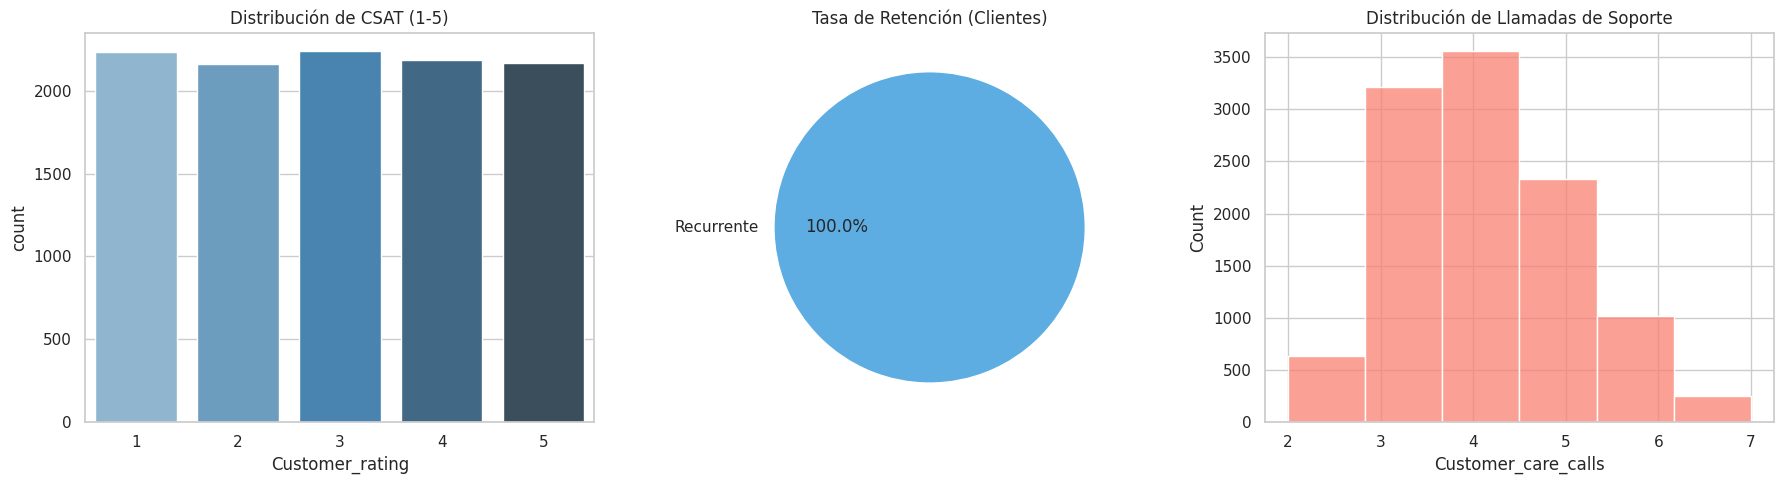

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Corrección de la Tasa de Retención
# Aseguramos que la columna 'Prior_purchases' sea numérica
data['Prior_purchases'] = pd.to_numeric(data['Prior_purchases'], errors='coerce')

# Definimos claramente los grupos
def clasificar_cliente(x):
    if pd.isna(x): return 'Desconocido'
    return 'Recurrente' if x >= 2 else 'Nuevo'

data['Tipo_Cliente'] = data['Prior_purchases'].apply(clasificar_cliente)
distribucion_clientes = data['Tipo_Cliente'].value_counts()

# 2. Visualización Corregida
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Customer_rating', data=data, ax=axes[0], palette='Blues_d')
axes[0].set_title('Distribución de CSAT (1-5)')

# Tasa de Retención: Gráfico de pastel ajustado
distribucion_clientes.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#5DADE2', '#AF7AC5'])
axes[1].set_title('Tasa de Retención (Clientes)')
axes[1].set_ylabel('')

# Carga de Soporte: Histograma ajustado
sns.histplot(data['Customer_care_calls'], kde=False, ax=axes[2], color='salmon', bins=6)
axes[2].set_title('Distribución de Llamadas de Soporte')

plt.tight_layout()
plt.show()

## Análisis de Resultados: Experiencia y Fidelización del Cliente

Los resultados de la experiencia post-venta permite identificar oportunidades de mejora en el servicio y en la lealtad del cliente:

### 1. Indicadores de Gestión
* **3.1 Índice de Satisfacción (CSAT):** La distribución de las calificaciones del 1 al 5 nos permite medir la percepción cualitativa. Una concentración en niveles bajos de esta escala es una señal de alerta sobre posibles fallos en el producto o en la logística.
* **3.2 Tasa de Retención:** Este indicador divide nuestra base de datos entre **Clientes Nuevos** y **Recurrentes**. La correcta proporción de ambos es vital para medir si nuestras estrategias de post-venta están generando lealtad real.
* **3.3 Carga de Soporte:** El análisis de llamadas de atención al cliente muestra la frecuencia de contacto post-venta. Un alto volumen de llamadas suele estar correlacionado con dudas sobre envíos o inconformidades con el producto, sirviendo como un indicador de fricción en la experiencia del usuario.
